In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("data.csv")
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [3]:
df['Bankrupt?'].value_counts()

Bankrupt?
0    6599
1     220
Name: count, dtype: int64

In [4]:
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

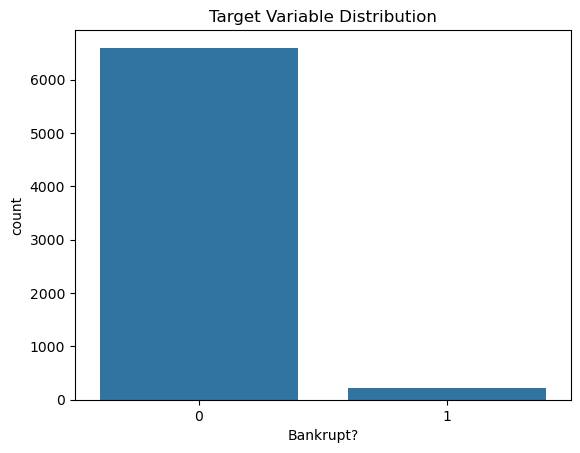

In [5]:
sns.countplot(x=y)
plt.title("Target Variable Distribution")
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [9]:
y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification report BEFORE SMOTE
print("\nClassification Report (Before SMOTE):\n")
print(classification_report(y_test, y_pred))

# Optional: dictionary format (if you want to extract values programmatically)
report_before = classification_report(y_test, y_pred, output_dict=True)
print("Recall (Class 1) Before SMOTE:", report_before['1']['recall'])
print("Precision (Class 1) Before SMOTE:", report_before['1']['precision'])
print("F1-score (Class 1) Before SMOTE:", report_before['1']['f1-score'])

Accuracy: 0.9626099706744868

Confusion Matrix:
 [[1307    6]
 [  45    6]]

Classification Report (Before SMOTE):

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1313
           1       0.50      0.12      0.19        51

    accuracy                           0.96      1364
   macro avg       0.73      0.56      0.59      1364
weighted avg       0.95      0.96      0.95      1364

Recall (Class 1) Before SMOTE: 0.11764705882352941
Precision (Class 1) Before SMOTE: 0.5
F1-score (Class 1) Before SMOTE: 0.19047619047619047


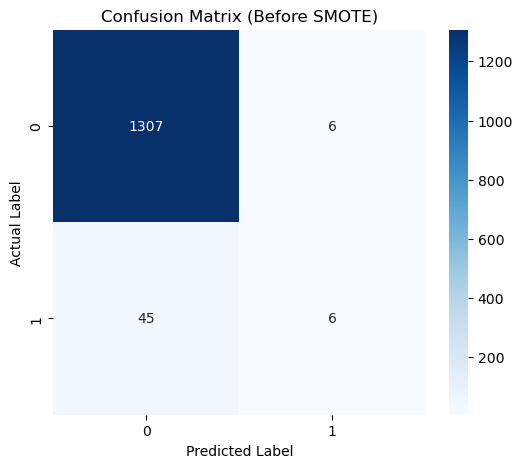

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Before SMOTE)")

plt.show()

In [12]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

Before SMOTE:
 Bankrupt?
0    5286
1     169
Name: count, dtype: int64

After SMOTE:
 Bankrupt?
0    5286
1    5286
Name: count, dtype: int64


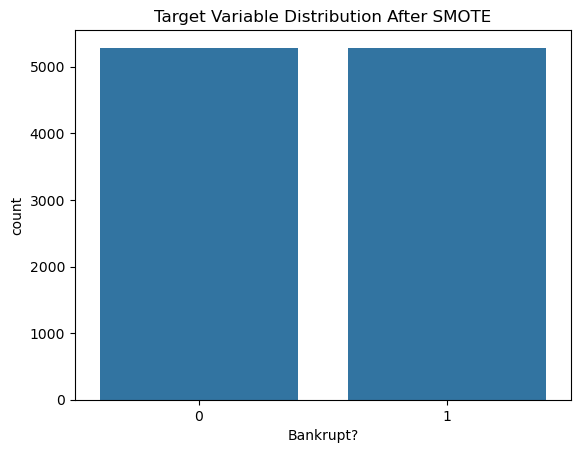

In [13]:
print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_smote.value_counts())

# Plot AFTER SMOTE
sns.countplot(x=y_train_smote)
plt.title("Target Variable Distribution After SMOTE")
plt.show()

In [14]:
from sklearn.metrics import classification_report

recalls = []

for k in range(1, 15):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_smote, y_train_smote)
    
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    recall_class1 = report['1']['recall']
    recalls.append(recall_class1)
    
    print(f"K={k}, Recall (class 1)={recall_class1:.3f}")

K=1, Recall (class 1)=0.647
K=2, Recall (class 1)=0.627
K=3, Recall (class 1)=0.843
K=4, Recall (class 1)=0.765
K=5, Recall (class 1)=0.843
K=6, Recall (class 1)=0.804
K=7, Recall (class 1)=0.824
K=8, Recall (class 1)=0.824
K=9, Recall (class 1)=0.843
K=10, Recall (class 1)=0.843
K=11, Recall (class 1)=0.843
K=12, Recall (class 1)=0.843
K=13, Recall (class 1)=0.843
K=14, Recall (class 1)=0.843


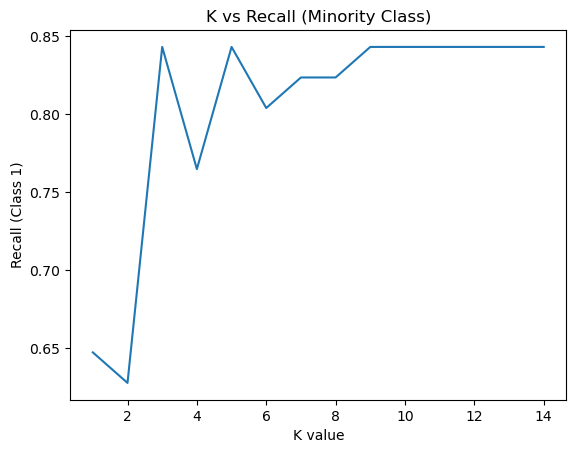

In [15]:
plt.plot(range(1, 15), recalls)
plt.xlabel("K value")
plt.ylabel("Recall (Class 1)")
plt.title("K vs Recall (Minority Class)")
plt.show()

In [16]:
best_k = recalls.index(max(recalls)) + 1
print("Best K:", best_k)

Best K: 3


In [17]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_smote, y_train_smote)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [18]:
y_pred = model.predict(X_test)

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.905425219941349

Confusion Matrix:
 [[1192  121]
 [   8   43]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.91      0.95      1313
           1       0.26      0.84      0.40        51

    accuracy                           0.91      1364
   macro avg       0.63      0.88      0.67      1364
weighted avg       0.97      0.91      0.93      1364



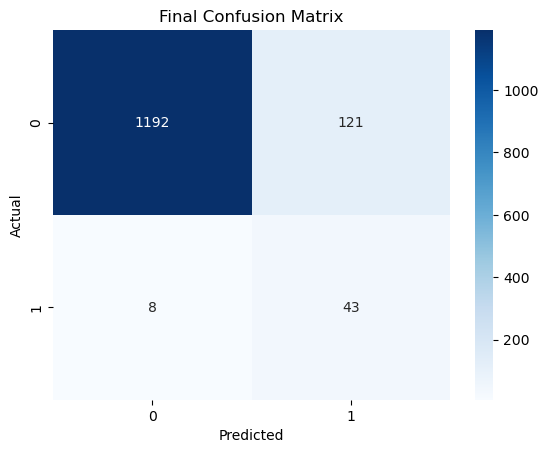

In [20]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Confusion Matrix")
plt.show()

In [21]:
from sklearn.metrics import roc_auc_score

# 1) Baseline model (before SMOTE)
model_base = KNeighborsClassifier(n_neighbors=5)
model_base.fit(X_train, y_train)

y_prob_base = model_base.predict_proba(X_test)[:, 1]
print("Baseline ROC-AUC:", roc_auc_score(y_test, y_prob_base))

# ... SMOTE + tuning steps ...

# 2) Final model (after SMOTE)
model_final = KNeighborsClassifier(n_neighbors=best_k)
model_final.fit(X_train_smote, y_train_smote)

y_prob_final = model_final.predict_proba(X_test)[:, 1]
print("Final ROC-AUC (After SMOTE):", roc_auc_score(y_test, y_prob_final))

Baseline ROC-AUC: 0.8400161283096635
Final ROC-AUC (After SMOTE): 0.8896480145752133
